# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('../data/yulu_rental.csv')

In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [3]:
month_to_india_season = {12:1, 1:1, 2:1,       # Winter
                          3:2, 4:2, 5:2,        # Summer
                          6:3, 7:3, 8:3, 9:3,   # Monsoon
                          10:4, 11:4}           # Post-Monsoon

df['weather_season_india'] = df['month'].map(month_to_india_season)
df['weather_season_india']

datetime
2011-01-01 00:00:00    1
2011-01-01 01:00:00    1
2011-01-01 02:00:00    1
2011-01-01 03:00:00    1
2011-01-01 04:00:00    1
                      ..
2012-12-19 19:00:00    1
2012-12-19 20:00:00    1
2012-12-19 21:00:00    1
2012-12-19 22:00:00    1
2012-12-19 23:00:00    1
Name: weather_season_india, Length: 10886, dtype: int64

In [4]:
df.head(10)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,weather_season_india
datetime,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0000,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0000,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0000,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0000,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0000,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4,1
2011-01-01 05:00:00,1,0,0,2,9.84,12.880,75,6.0032,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,5,1
2011-01-01 06:00:00,1,0,0,1,9.02,13.635,80,0.0000,2,0,2,2011-01-01,1,52,5,Saturday,2011,1,6,1
2011-01-01 07:00:00,1,0,0,1,8.20,12.880,86,0.0000,1,2,3,2011-01-01,1,52,5,Saturday,2011,1,7,1
2011-01-01 08:00:00,1,0,0,1,9.84,14.395,75,0.0000,1,7,8,2011-01-01,1,52,5,Saturday,2011,1,8,1


## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 10886 entries, 2011-01-01 00:00:00 to 2012-12-19 23:00:00
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   season                10886 non-null  int64  
 1   holiday               10886 non-null  int64  
 2   workingday            10886 non-null  int64  
 3   weather               10886 non-null  int64  
 4   temp                  10886 non-null  float64
 5   atemp                 10886 non-null  float64
 6   humidity              10886 non-null  int64  
 7   windspeed             10886 non-null  float64
 8   casual                10886 non-null  int64  
 9   registered            10886 non-null  int64  
 10  count                 10886 non-null  int64  
 11  date                  10886 non-null  object 
 12  day                   10886 non-null  int32  
 13  week                  10886 non-null  UInt32 
 14  weekday_num           10886 non-nul

In [6]:
print(f'Кількість рядків: {df.shape[0]}, кількість стовпців: {df.shape[1]}')

Кількість рядків: 10886, кількість стовпців: 20


In [ ]:
Кожен рядок датафрейму відповідає одній годині, тобто яка кількість велосипедів була орендована за конкретну годину 

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


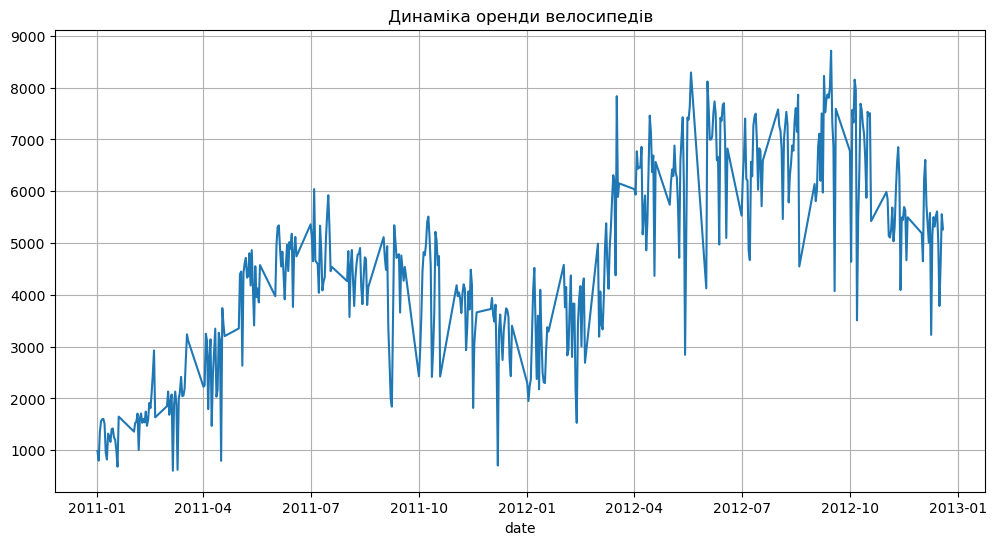

In [67]:
rent_by_day = df.groupby('date')['count'].sum()
rent_by_day.plot.line(
    figsize = (12,6),
    title = "Динаміка оренди велосипедів",
    grid = True
);

In [ ]:
1. Заломи на графіку виникають через щоденні коливання кількості оренд, які спричиняють зовнішні фактори: температура, вологість,
опади. Через це точки на графіку не зʼєднуються плавно і графік отримує зигзаги. Прибрати заломи можна знизивши деталізацію даних,
згрупувавши їх помісячно.
2-3. На графіку спостерігається чітке зростання кількості оренд протягом усього періоду: з 800-1000 оренд на день на початку 2011 
року до 7000-8000 оренд в кінці 2012. Зростання відбувається нерівномірно, адже піком оренд є червень-вересень через сприятливі 
погодні умови в Індії, а спад припадає на зиму з пониженням температури.
4.На графіку є декілька аномальних значень в порівнянні з досить високим рівнем оренд. Такі аномалії може спричинити погіршення 
погодніх умов, локальне свято або збій системи або додатку для оренд


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

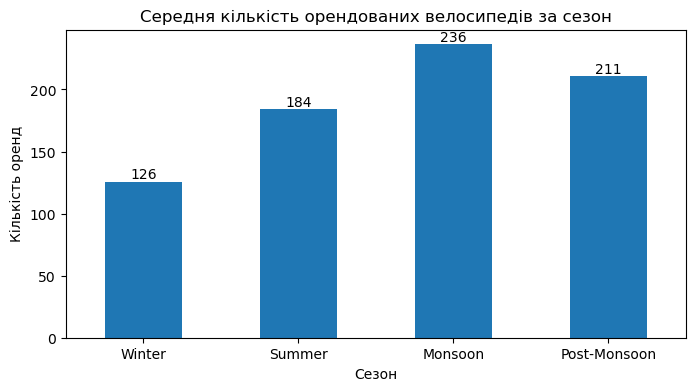

In [69]:
avg_q_rent = df.groupby('weather_season_india')['count'].mean()
ax = avg_q_rent.plot.bar(
    figsize = (8,4),
    title = 'Середня кількість орендованих велосипедів за сезон',
    xlabel = 'Сезон',
    ylabel = 'Кількість оренд')
plt.xticks(rotation = 0)
ax.set_xticklabels(['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'])
ax.bar_label(ax.containers[0], fmt='%.0f');    #для додавання позначок над стовпцями я скористалася допомогою ШІ;

In [ ]:
1. Найбільша середня кількість оренди велосипедів припадає на сезон Monsoon (June–September) і сягає
236 оренд на годину.
2. Сезонну закономірність можна легко пояснити, подивившись на погодні умови періодів. Пік оренд настає з червня по вересень
через найкомфортнішу температуру та сухість повітря для катання.
3.Оренда велосипедів у найпопулярніший квартал (211 оренд/год у середньому) у 1.67 раза (тобто на 67.5%) перевищує оренду в
найменш популярний квартал (126 оренд/год).

In [72]:
df.groupby('weather_season_india')[['temp', 'humidity', 'windspeed']].mean().round(2)

,temp,humidity,windspeed
weather_season_india,,,
1,11.84,60.26,13.06
2,19.11,60.17,14.41
3,28.36,62.78,11.72
4,18.06,65.07,12.18


## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


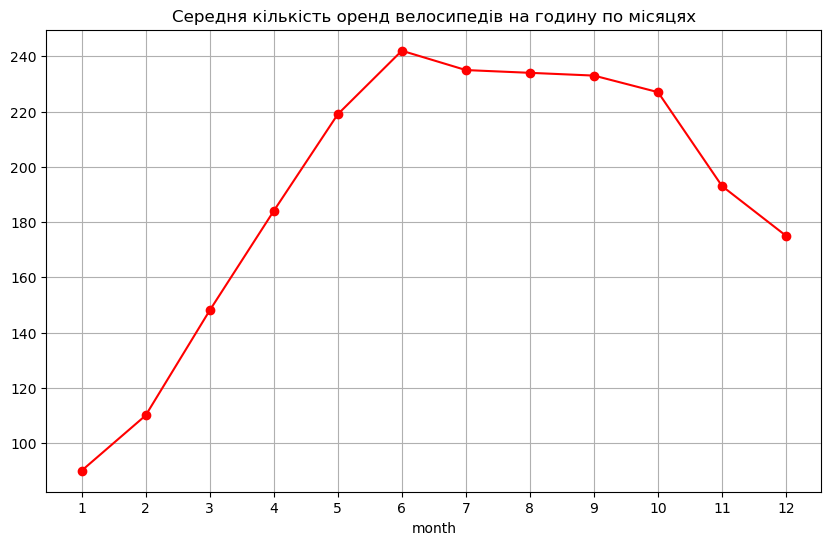

In [9]:
rent_per_hour = df.groupby('month')['count'].mean().astype(int)

ax = rent_per_hour.plot.line(
    figsize = (10,6),
    marker = 'o',
    title = 'Середня кількість оренд велосипедів на годину по місяцях',
    grid = True,
    color = 'red')
ax.set_xticks([1,2,3,4,5,6,7,8,9,10,11,12]);

In [ ]:
1.Пік оренди спостерігається в червні (близько 240 оренд на годину), а спад припадає на грудень-січень
2.Результати збігаються з попередніми твердженнями
3.Клімат впливає на оренду насамперед через температуру: у холодні місяці (грудень-лютий) їзда некомфортна і попит падає, а в 
теплі (травень-вересень) — зростає, причому додатково знижують оренду висока вологість, опади та сильний вітер, які роблять 
катання незручним чи небезпечним незалежно від температури.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

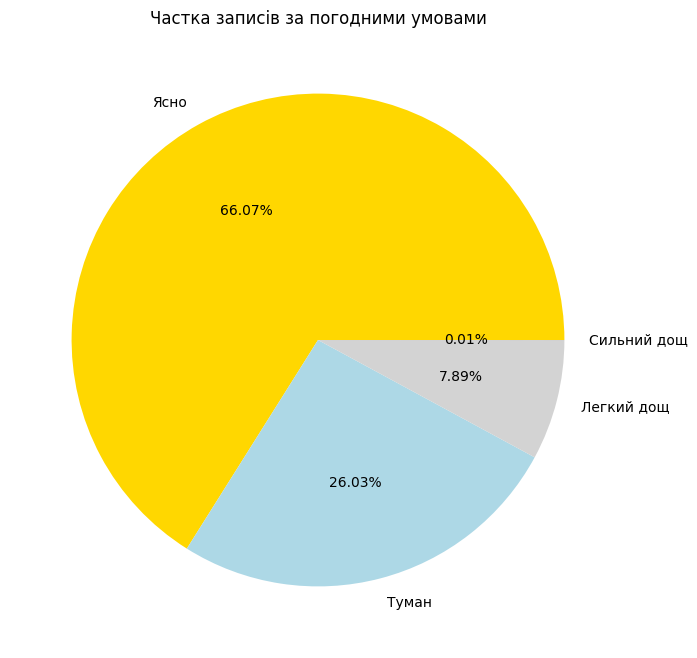

In [10]:
weather_counts = df['weather'].value_counts(normalize=True)
weather_counts

weather
1    0.660665
2    0.260334
3    0.078909
4    0.000092
Name: proportion, dtype: float64

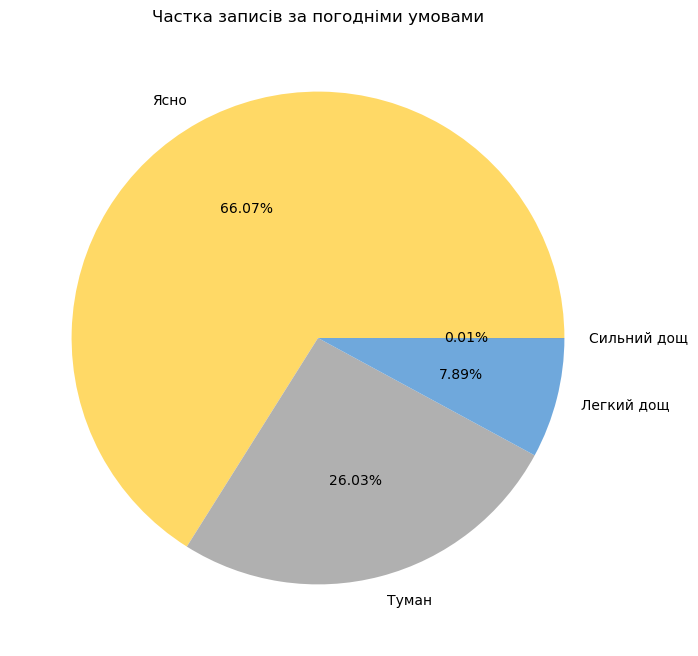

In [11]:
weather_counts.plot.pie(
    figsize = (8,8),
    labels = ['Ясно', 'Туман','Легкий дощ', 'Сильний дощ'],
    autopct ='%1.2f%%',
    title = 'Частка записів за погодніми умовами',
    ylabel = '',
   colors = ['#FFD966', '#B0B0B0', '#6FA8DC', '#2C3E50']);

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

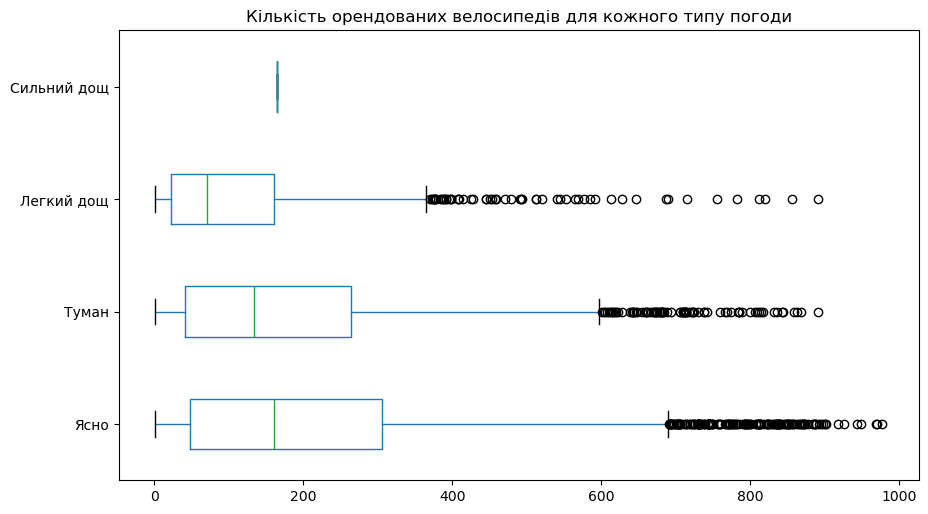

In [23]:
ax = df.boxplot(
    column = 'count',
    by = 'weather',
    figsize = (10,6),
    vert = False,
    grid = False
    )
plt.title('Кількість орендованих велосипедів для кожного типу погоди')
plt.ylabel ('')
plt.suptitle('')
ax.set_yticklabels(['Ясно', 'Туман','Легкий дощ', 'Сильний дощ']);

In [73]:
df.groupby('weather')['count'].mean()

weather
1    205.236791
2    178.955540
3    118.846333
4    164.000000
Name: count, dtype: float64

In [76]:
df['weather'].value_counts()

weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64

In [ ]:
1.Найбільший розкид даних про оренду спостерігається за ясної погоди (від 0 до майже 1000 оренд на годину), а 50% основних 
спостережень зосереджені в межах від ~50 до ~340
2. В усіх боксплотах погодних умов є викиди, проте для категорії «Сильний дощ» даних замало (тільки одне значення) для побудовикоробки з вусами.
3. Пи ясній погоді медіанне значення є найвищим серед усіх категорій і сягає 205 орендам на годину

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

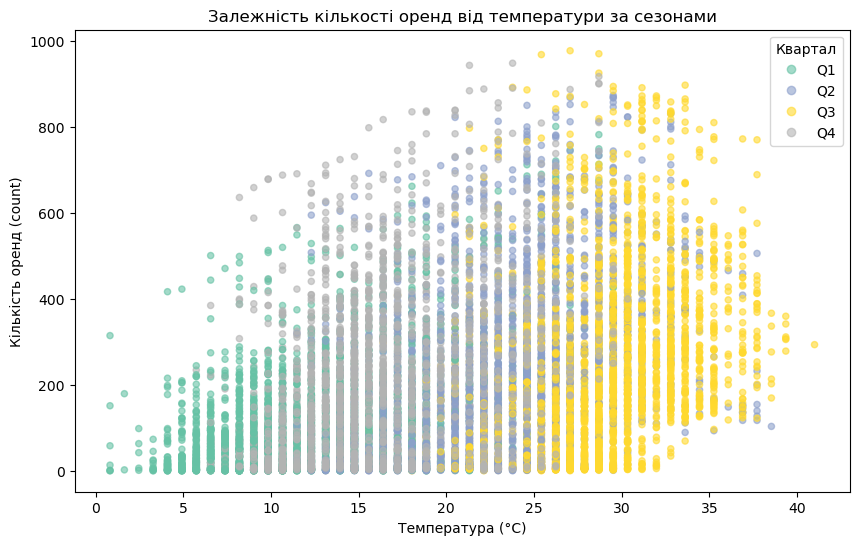

In [47]:
ax = df.plot.scatter(
    x = 'temp',
    y = 'count',
    c = 'season',
    cmap='Set2',
    alpha = 0.6,
    figsize = (10,6),
    colorbar=False
)
ax.set_title('Залежність кількості оренд від температури за сезонами')
ax.set_xlabel('Температура (°C)')
ax.set_ylabel('Кількість оренд (count)')

scatter = ax.collections[0]
handles, labels = scatter.legend_elements()
ax.legend(handles, ['Q1', 'Q2', 'Q3', 'Q4'], title='Квартал');   #Для написання цієї частини коду використала ШІ


In [ ]:
На графіку спостерігається позитивна кореляція - з підвищенням температури кількість оренд зростає.
Більша кількість оренд спостерігається за температури 20-30 градусів і зростає до значення 700 - 1000.
При низьких температурах (0–10 градусів) кількість оренд рідко перевищує 400 на годину, а більшість точок зосереджена в нижньому
діапазоні (до 200).
Після настання спекотної погоди (30-40 градусів) зростання припиняється, оскільки надмірна спека не є комфортною для катання

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

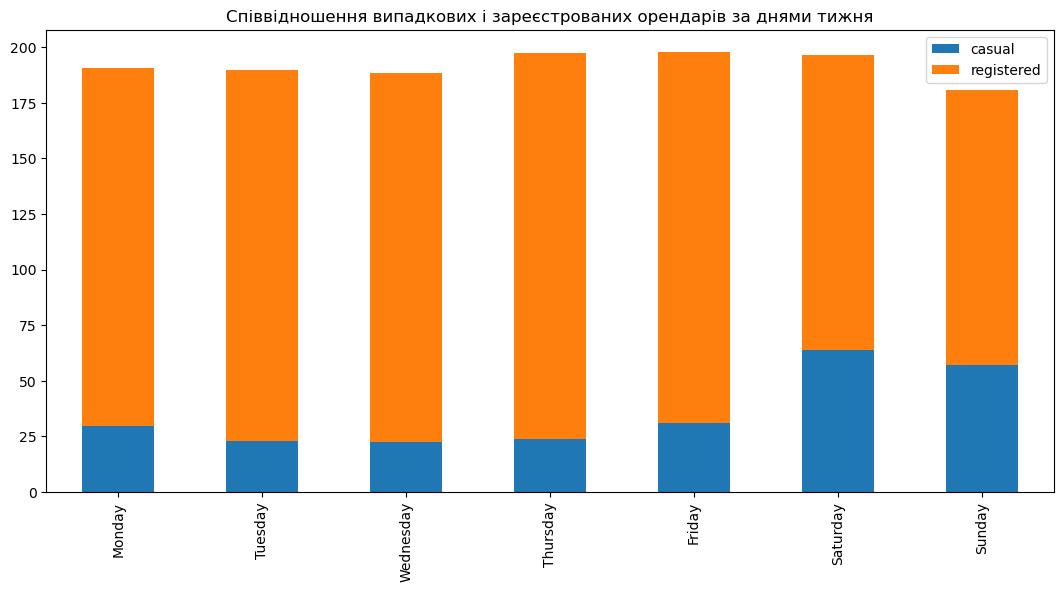

In [61]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = df.groupby('weekday')[['casual','registered']].mean()
weekday_avg = weekday_avg.reindex(day_order)
ax = weekday_avg.plot.bar(
    stacked = True,
    figsize = (13,6),
    xlabel = '',
    title = 'Співвідношення випадкових і зареєстрованих орендарів за днями тижня');

In [ ]:
Найбільша кількість оренд від зареєстрованих користувачів спостерігається в будні дні, а особливо в 
четвер та пʼятницю (близько 160 оренд на год). Поведінку двох груп користувачів можна пояснити наступним чином: зареєстровані
клієнти - це переважно жителі міста, які ймовірно, користуються велосипедами для щоденних поїздок на роботу або навчання, а 
найвища активніть незареєстрованих користувачів спостерігається у вихідні дні, оскільки в місті може бути більше туристів, 
яким потрібно добиратися на велосипеді з пункту А в пункт Б для прогулянок без потреби реєстрації